# Resampling with Michaud Model

In [1]:
# Cella 1: Download dei dati e definizione dell'universo pulito
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Dizionario mappato sui ticker scelti (senza i 4 con missing data)
etf_universe = {
    "SPY": "S&P 500", "QQQ": "Nasdaq-100", "VGK": "Europe", 
    "EWJ": "Japan", "VPL": "Asia-Pacific", "EEM": "MSCI EM", 
    "VWO": "FTSE EM", "SHY": "1-3Y Treasury", "IEF": "7-10Y Treasury", 
    "TLT": "20+Y Treasury", "IGOV": "Intl Treasury", "EMB": "EM Bond USD", 
    "LQD": "IG Corporate", "HYG": "High Yield", "GLD": "Gold", 
    "SLV": "Silver", "DBC": "Broad Commodity", "XLE": "Energy Equity", 
    "TIP": "TIPS", "VNQ": "US REIT", "BIL": "T-Bill (Risk-Free)", "USO": "Oil"
}

tickers = list(etf_universe.keys())

print("Download dei dati in corso...")
prices_daily = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices_daily = prices_daily.dropna(how="all")

print(f"Dimensioni dataset giornaliero: {prices_daily.shape}")

Download dei dati in corso...


[*********************100%***********************]  22 of 22 completed

Dimensioni dataset giornaliero: (4126, 22)


In [2]:
# Cella 2: Resampling mensile, log-rendimenti e calcolo metriche storiche
prices_monthly = prices_daily.resample('ME').last()
log_returns_monthly = np.log(prices_monthly / prices_monthly.shift(1)).dropna(how="all")

# Metriche annualizzate
ann_returns = log_returns_monthly.mean() * 12
ann_volatility = log_returns_monthly.std() * np.sqrt(12)

# Sharpe Ratio (utilizziamo BIL come proxy per il tasso risk-free)
risk_free_rate = ann_returns['BIL']
sharpe_ratio = (ann_returns - risk_free_rate) / ann_volatility

# Maximum Drawdown
cumulative_returns = np.exp(log_returns_monthly.cumsum())
running_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns / running_max) - 1
max_drawdown = drawdowns.min()

# Creazione DataFrame riassuntivo
eda_metrics = pd.DataFrame({
    'Classe/Asset': pd.Series(etf_universe),
    'Rendimento Ann.': ann_returns,
    'Volatilità Ann.': ann_volatility,
    'Sharpe Ratio': sharpe_ratio,
    'Max Drawdown': max_drawdown
})

display(eda_metrics.round(4).sort_values(by='Sharpe Ratio', ascending=False))

,Classe/Asset,Rendimento Ann.,Volatilità Ann.,Sharpe Ratio,Max Drawdown
QQQ,Nasdaq-100,0.1830,0.1741,0.9770,-0.3258
SPY,S&P 500,0.1373,0.1441,0.8623,-0.2393
HYG,High Yield,0.0532,0.0750,0.5359,-0.1525
VPL,Asia-Pacific,0.0802,0.1524,0.4410,-0.2815
GLD,Gold,0.0839,0.1611,0.4402,-0.4291
VNQ,US REIT,0.0891,0.1733,0.4389,-0.3275
EWJ,Japan,0.0706,0.1432,0.4022,-0.2886
VGK,Europe,0.0754,0.1759,0.3550,-0.3096
LQD,IG Corporate,0.0388,0.0729,0.3537,-0.2326
EMB,EM Bond USD,0.0444,0.0927,0.3384,-0.2674


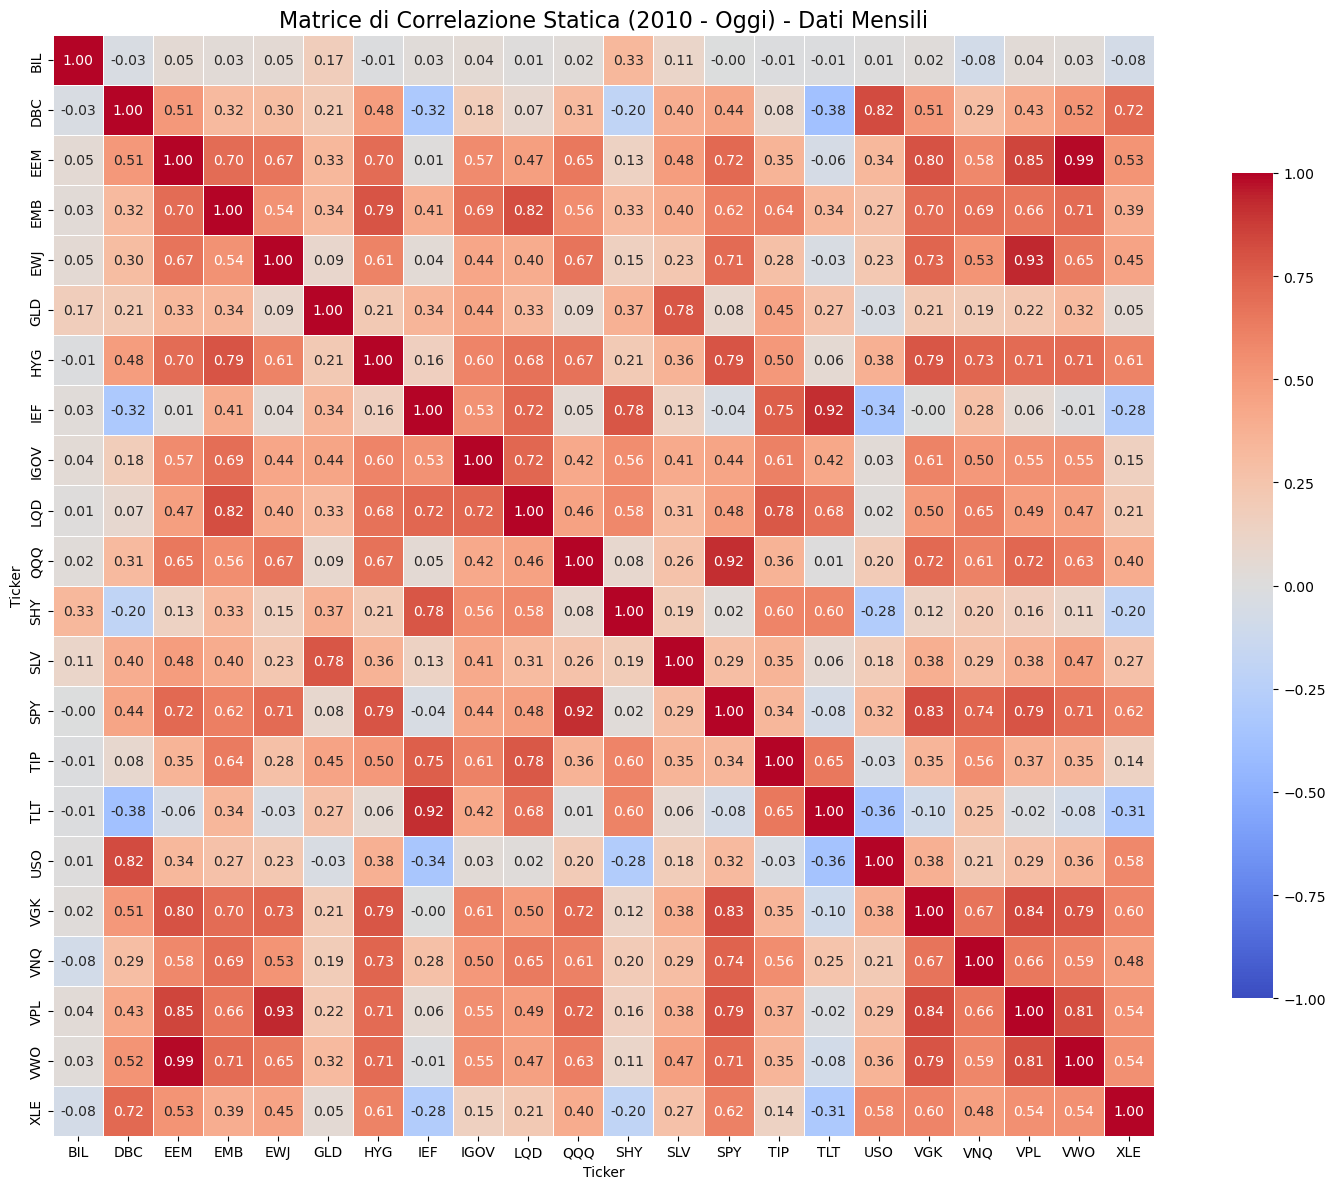

In [3]:
# Cella 3: Matrice di Correlazione di Pearson (Lungo Periodo)
corr_matrix_monthly = log_returns_monthly.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix_monthly, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .75}
)
plt.title("Matrice di Correlazione Statica (2010 - Oggi) - Dati Mensili", fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# Cella 1: Funzioni Core di Markowitz
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utilizziamo la nostra matrice incondizionata dai dati mensili (2010 - 2026)
mu_v = ann_returns.values # Vettore dei rendimenti storici annualizzati (dalla EDA)
S = ann_volatility.values[:, None] * corr_matrix_monthly.values * ann_volatility.values[None, :]
n = len(tickers)
asset_names = tickers
MONTHS_PER_YEAR = 12

def mvp(mu, cov):
    """Calcola il Minimum Variance Portfolio (Estremo sinistro della frontiera)."""
    n_assets = len(mu)
    def obj(w):
        return w @ cov @ w
    # Vincolo fully invested e long-only
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bnds = tuple((0.0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    return minimize(obj, w0, method='SLSQP', bounds=bnds, constraints=cons)

def min_var_for_target(target_ret, mu, cov):
    """Minimizza la varianza per un rendimento target dato (Crea i punti della frontiera)."""
    n_assets = len(mu)
    def obj(w):
        return w @ cov @ w
    # 1. Raggiungere il target return
    # 2. Fully invested
    cons = [{'type': 'eq', 'fun': lambda w: w @ mu - target_ret},
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bnds = tuple((0.0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    return minimize(obj, w0, method='SLSQP', bounds=bnds, constraints=cons)

In [5]:
# Cella 2: L'Algoritmo di Ricampionamento (Michaud)
np.random.seed(7) # Per riproducibilità

B = 100 # Numero di simulazioni Monte Carlo
K = 30  # Numero di portafogli calcolati lungo la frontiera (dal MVP al max return)
T = 60  # La finestra campionaria stabilita (5 anni di osservazioni mensili)

# I modelli normali multivariati di Numpy necessitano di input con granularità mensile
mu_m = mu_v / MONTHS_PER_YEAR
S_m  = S / MONTHS_PER_YEAR

def run_resampling(B, K, T_sim, mu_m, S_m, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    all_W = np.full((B, K, n), np.nan)
    all_sim_vol = np.full((B, K), np.nan)
    all_sim_ret = np.full((B, K), np.nan)
    
    print(f"Esecuzione di {B} simulazioni Monte Carlo in corso...")
    
    for b in range(B):
        # 1. Creazione dell'universo parallelo (Simulazione)
        sim = np.random.multivariate_normal(mu_m, S_m, size=T_sim)
        sim_mu = sim.mean(axis=0) * MONTHS_PER_YEAR
        sim_S  = np.cov(sim.T) * MONTHS_PER_YEAR
        
        # 2. Trova il portafoglio minimo rischio nel nuovo universo
        mvp_b = mvp(sim_mu, sim_S)
        if not mvp_b.success: continue
        mvp_b_ret = mvp_b.x @ sim_mu
        
        max_ret = sim_mu.max() * 0.999 # Rendimento massimo ottenibile
        if max_ret <= mvp_b_ret: continue
            
        # 3. Traccia K punti equidistanti sulla frontiera simulata
        targets_b = np.linspace(mvp_b_ret, max_ret, K)
        
        for k, t in enumerate(targets_b):
            r = min_var_for_target(t, sim_mu, sim_S)
            if r.success:
                w = r.x
                all_W[b, k] = w
                all_sim_vol[b, k] = np.sqrt(w @ sim_S @ w)
                all_sim_ret[b, k] = w @ sim_mu
                
    return all_W, all_sim_vol, all_sim_ret

# Esecuzione del ricampionamento standard
all_W, all_sim_vol, all_sim_ret = run_resampling(B, K, T, mu_m, S_m, seed=7)
print(f'Done: B={B}, K={K}, T_sim={T} (full)')

Esecuzione di 100 simulazioni Monte Carlo in corso...
Done: B=100, K=30, T_sim=60 (full)


In [6]:
# Cella 3: Calcolo Frontiera Media e Baseline
def aggregate_weights_mean(all_W):
    """Media dei vettori di peso tra i vari resample (rango per rango)."""
    W_agg = np.nanmean(all_W, axis=0)
    # Ribilanciamo a 1 la somma in caso di micro-approssimazioni
    s = W_agg.sum(axis=1, keepdims=True)
    s[s == 0] = 1
    return W_agg / s

def eval_on_original(W_agg, mu_v, S):
    """Valuta un portafoglio rispetto alla matrice di covarianza storica reale."""
    vol = np.sqrt(np.einsum('ki,ij,kj->k', W_agg, S, W_agg))
    ret = W_agg @ mu_v
    order = np.argsort(vol)
    return vol[order], ret[order], W_agg[order]

W_avg = aggregate_weights_mean(all_W)
vol_avg, ret_avg, W_avg = eval_on_original(W_avg, mu_v, S)

# --- Calcolo della Baseline (Markowitz Classico) per confronto ---
baseline_W = np.zeros((K, n))
baseline_vol = np.zeros(K)
baseline_ret = np.zeros(K)

mvp0 = mvp(mu_v, S)
r_mvp = mvp0.x @ mu_v
r_max = mu_v.max() * 0.999
targets0 = np.linspace(r_mvp, r_max, K)

for k, t in enumerate(targets0):
    res = min_var_for_target(t, mu_v, S)
    if res.success:
        baseline_W[k] = res.x
        baseline_vol[k] = np.sqrt(res.x @ S @ res.x)
        baseline_ret[k] = res.x @ mu_v
        
vol0 = baseline_vol
ret0 = baseline_ret

# Valutazione di tutte le singole simulazioni sulla matrice originale
all_orig_vol = np.sqrt(np.einsum('bki,ij,bkj->bk', np.nan_to_num(all_W), S, np.nan_to_num(all_W)))
all_orig_ret = np.nan_to_num(all_W) @ mu_v
mask = ~np.isnan(all_W).any(axis=2)
print('Aggregazione e Baseline completate.')

Aggregazione e Baseline completate.


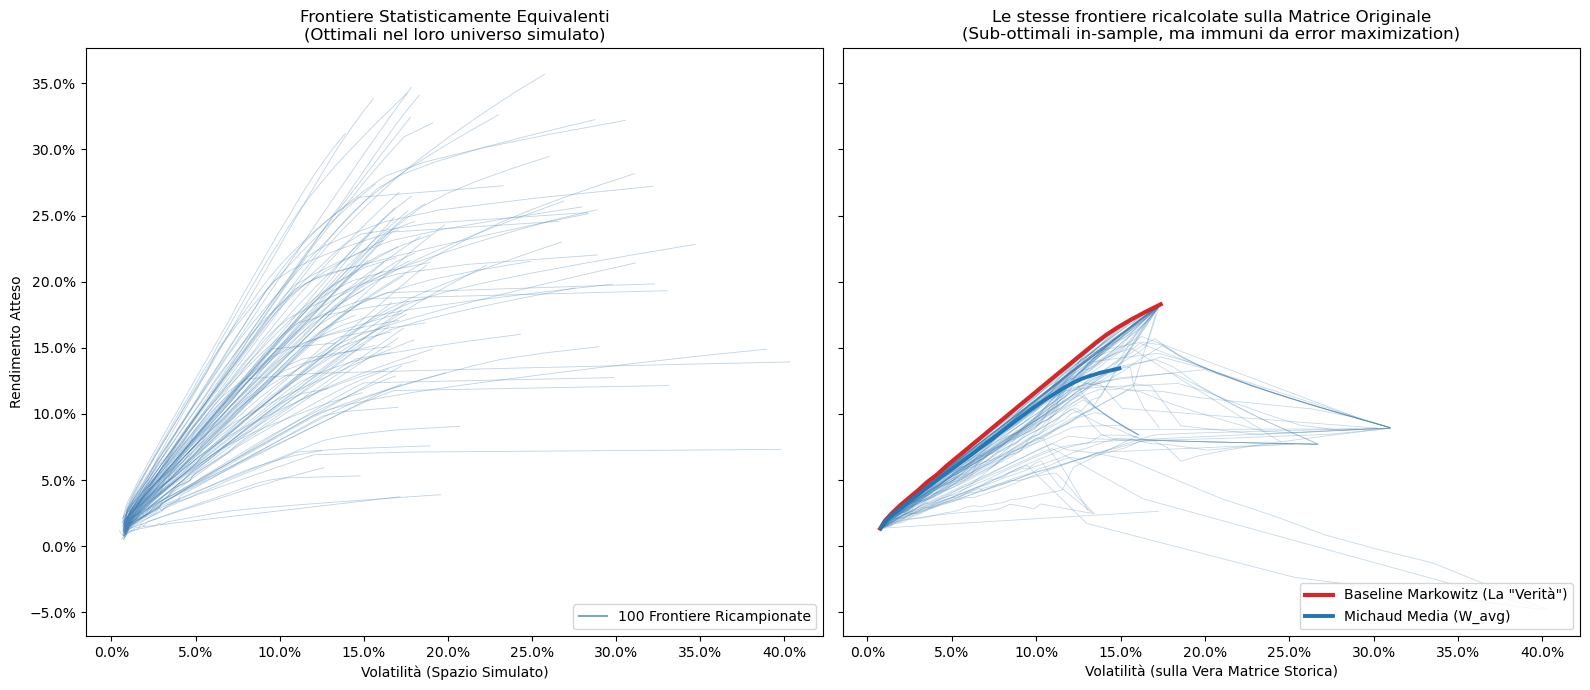

In [7]:
# Cella 4: Visualizzazione 1 - Le Frontiere a confronto
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# SINISTRA: L'illusione dell'ottimalità nelle simulazioni
for b in range(B):
    if mask[b].any():
        v = all_sim_vol[b][mask[b]]
        r = all_sim_ret[b][mask[b]]
        order = np.argsort(v)
        axes[0].plot(v[order], r[order], color='steelblue', lw=0.6, alpha=0.35)
axes[0].plot([], [], color='steelblue', lw=1.5, alpha=0.7, label=f'{B} Frontiere Ricampionate')
axes[0].set_xlabel('Volatilità (Spazio Simulato)')
axes[0].set_ylabel('Rendimento Atteso')
axes[0].set_title('Frontiere Statisticamente Equivalenti\n(Ottimali nel loro universo simulato)')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[0].legend(loc='lower right')

# DESTRA: La sub-ottimalità in-sample, ma maggiore robustezza
for b in range(B):
    if mask[b].any():
        v = all_orig_vol[b][mask[b]]
        r = all_orig_ret[b][mask[b]]
        order = np.argsort(v)
        axes[1].plot(v[order], r[order], color='steelblue', lw=0.6, alpha=0.3)
axes[1].plot(vol0, ret0, color='#d62728', lw=3, label='Baseline Markowitz (La "Verità")')
axes[1].plot(vol_avg, ret_avg, color='#1f77b4', lw=2.8, label='Michaud Media (W_avg)')
axes[1].set_xlabel('Volatilità (sulla Vera Matrice Storica)')
axes[1].set_title('Le stesse frontiere ricalcolate sulla Matrice Originale\n(Sub-ottimali in-sample, ma immuni da error maximization)')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

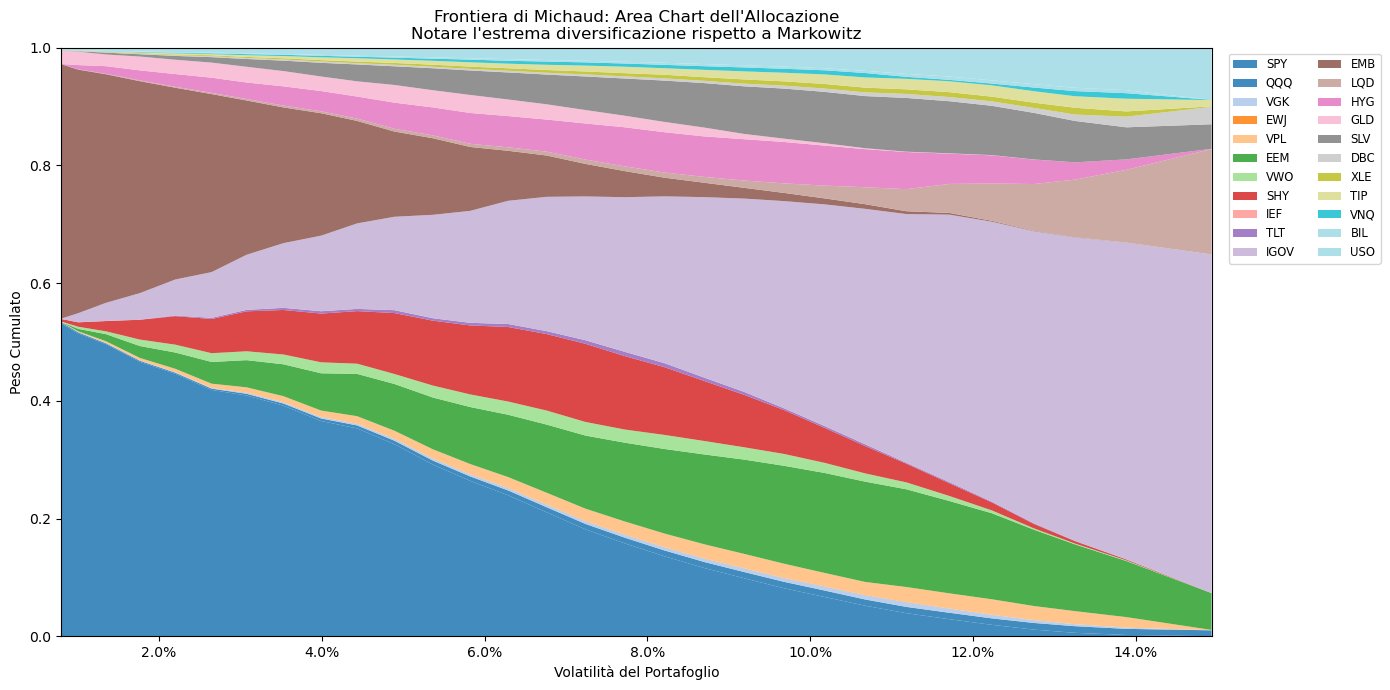

In [8]:
# Cella 5: Visualizzazione 2 - Composizione dei Pesi
colors = plt.cm.tab20(np.linspace(0, 1, n)) # tab20 permette di distinguere 20+ colori
fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(vol_avg, W_avg.T, labels=asset_names, colors=colors, alpha=0.85)
ax.set_xlim(vol_avg.min(), vol_avg.max())
ax.set_ylim(0, 1)
ax.set_xlabel('Volatilità del Portafoglio')
ax.set_ylabel('Peso Cumulato')
ax.set_title("Frontiera di Michaud: Area Chart dell'Allocazione\nNotare l'estrema diversificazione rispetto a Markowitz")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

### Half Amplitude Resampling ###


Esecuzione variante Half-Amplitude (Maggiore incertezza statistica)...
Esecuzione di 100 simulazioni Monte Carlo in corso...


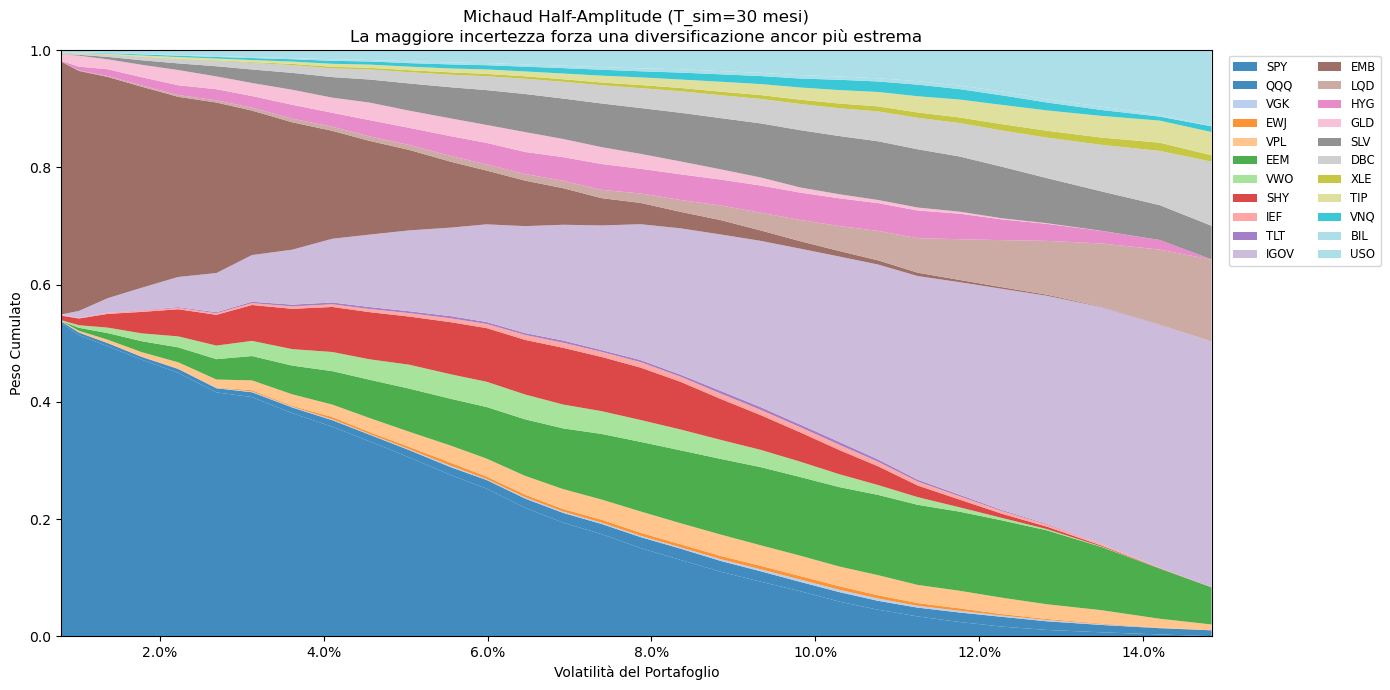

In [9]:
# Cella 6: Half-Amplitude Resampling (Maggior incertezza)
T_half = T // 2
print("\nEsecuzione variante Half-Amplitude (Maggiore incertezza statistica)...")
all_W_h, all_sim_vol_h, all_sim_ret_h = run_resampling(B, K, T_half, mu_m, S_m, seed=11)

W_avg_h = aggregate_weights_mean(all_W_h)
vol_avg_h, ret_avg_h, W_avg_h = eval_on_original(W_avg_h, mu_v, S)

fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(vol_avg_h, W_avg_h.T, labels=asset_names, colors=colors, alpha=0.85)
ax.set_xlim(vol_avg_h.min(), vol_avg_h.max())
ax.set_ylim(0, 1)
ax.set_xlabel('Volatilità del Portafoglio')
ax.set_ylabel('Peso Cumulato')
ax.set_title("Michaud Half-Amplitude (T_sim=30 mesi)\nLa maggiore incertezza forza una diversificazione ancor più estrema")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

## Sensitivity & Perturbation

In [10]:
# ==========================================
# SEZIONE: SENSITIVITY ANALYSIS E PERTURBAZIONE
# ==========================================

# Assicuriamoci di avere le volatilità singole per i grafici successivi
sigma = ann_volatility.values 

# Funzione helper per costruire rapidamente l'intera frontiera dato un mu e un cov
def build_frontier(mu, cov, K_points=30):
    res_mvp = mvp(mu, cov)
    if not res_mvp.success: return [], [], []
    r_min = res_mvp.x @ mu
    r_max = mu.max() * 0.999
    if r_max <= r_min: return [], [], []
    
    targets = np.linspace(r_min, r_max, K_points)
    vols, rets, weights = [], [], []
    
    for t in targets:
        res = min_var_for_target(t, mu, cov)
        if res.success:
            w = res.x
            vols.append(np.sqrt(w @ cov @ w))
            rets.append(w @ mu)
            weights.append(w)
            
    return np.array(vols), np.array(rets), np.array(weights)

# 1. Generazione di 20 scenari perturbati
SHOCK_STD = 0.01  # 1% std (il 95% degli shock sarà circa entro il +/- 2%)
np.random.seed(123)
K_PERT = 20
perturbed = []

print(f"Generazione di {K_PERT} frontiere perturbate in corso...")
for k in range(K_PERT):
    eps = np.zeros(n)
    for i in range(n):
        # Estrazione della magnitudo dell'errore e lancio della moneta per il segno
        mag = abs(np.random.normal(0, SHOCK_STD))
        eps[i] = mag if np.random.random() < 0.5 else -mag
        
    mu_p = mu_v + eps
    v, r, W = build_frontier(mu_p, S, K_points=30)
    
    if len(v) > 0:
        perturbed.append({'k': k, 'eps': eps, 'mu': mu_p, 'vol': v, 'ret': r, 'W': W})

# 2. Quantificazione dell'impatto e ricerca del "Worst Case"
# Per confrontare i pesi, dobbiamo allinearli agli stessi livelli di volatilità della baseline (vol0)
impacts = []
for p in perturbed:
    # Interpolazione lineare dei pesi sulla griglia di volatilità originale
    Wp_interp = np.array([np.interp(vol0, p['vol'], p['W'][:, j]) for j in range(n)]).T
    # Calcolo della massima distanza assoluta (Norma L1)
    impacts.append(np.abs(Wp_interp - baseline_W).sum(axis=1).max())

most_idx = int(np.argmax(impacts))
print(f'Calcolate {len(perturbed)} frontiere perturbate con successo.')
print(f'Perturbazione con maggior impatto: Indice {most_idx} (Distanza L1 Max = {impacts[most_idx]:.2f})')

n_up = (perturbed[most_idx]["eps"] > 0).sum()
print(f' -> {n_up} Shock POSITIVI (UP) / {n - n_up} Shock NEGATIVI (DOWN)')

Generazione di 20 frontiere perturbate in corso...
Calcolate 20 frontiere perturbate con successo.
Perturbazione con maggior impatto: Indice 0 (Distanza L1 Max = 1.02)
 -> 11 Shock POSITIVI (UP) / 11 Shock NEGATIVI (DOWN)


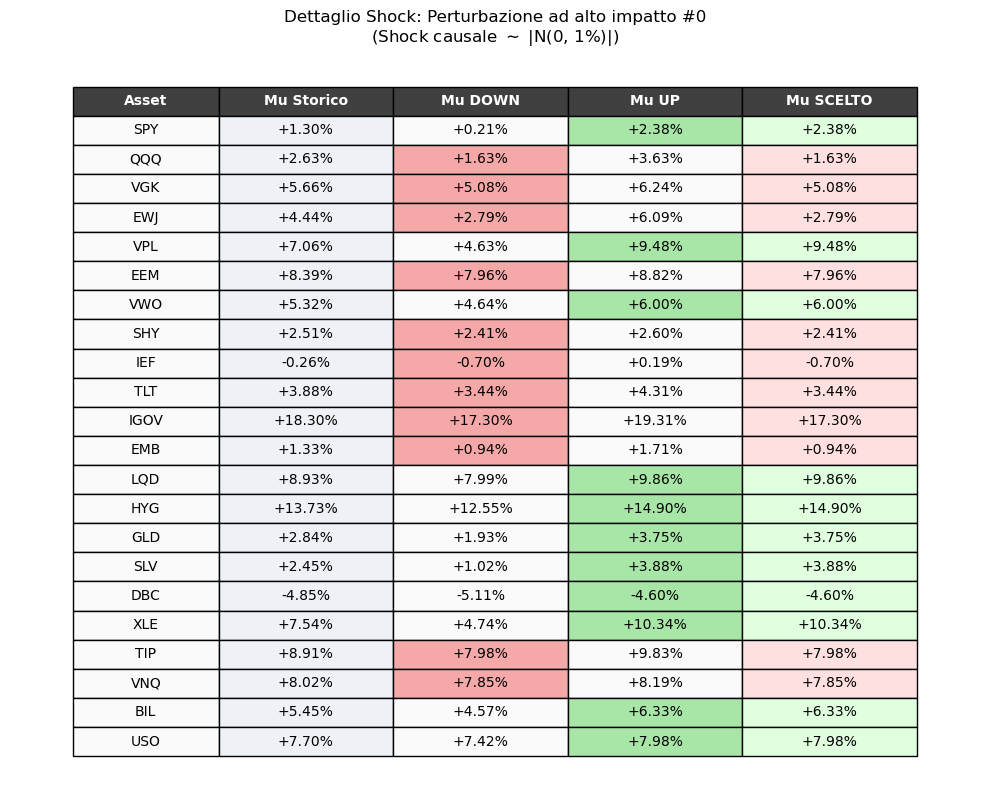

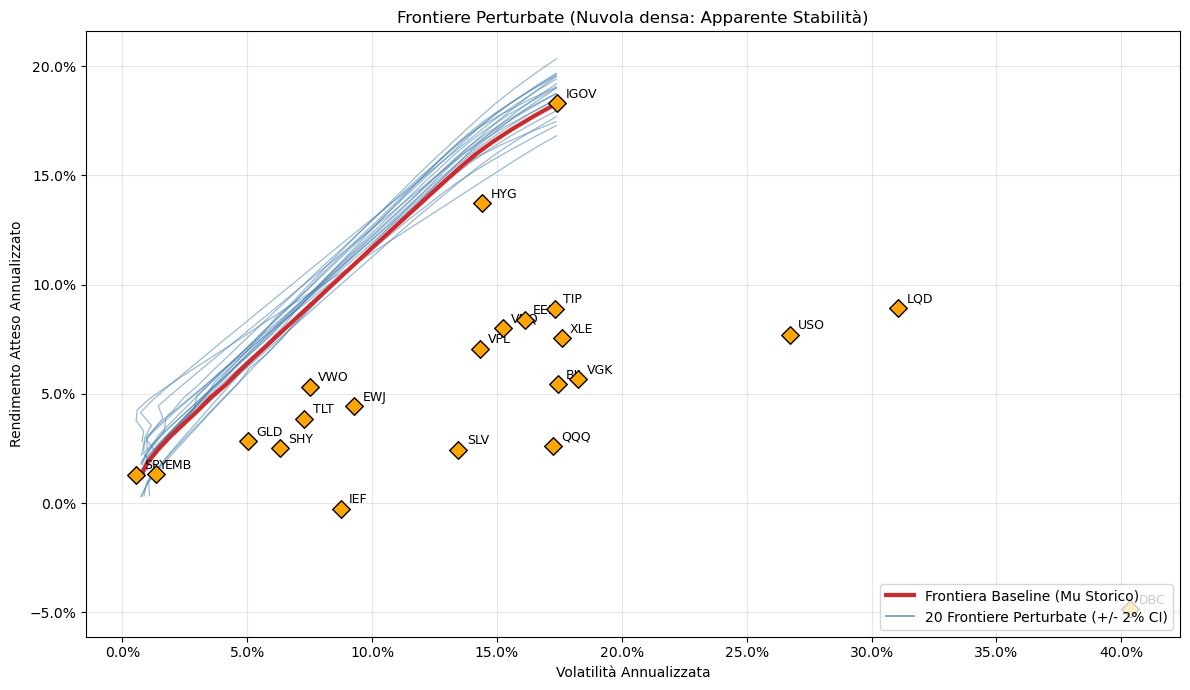

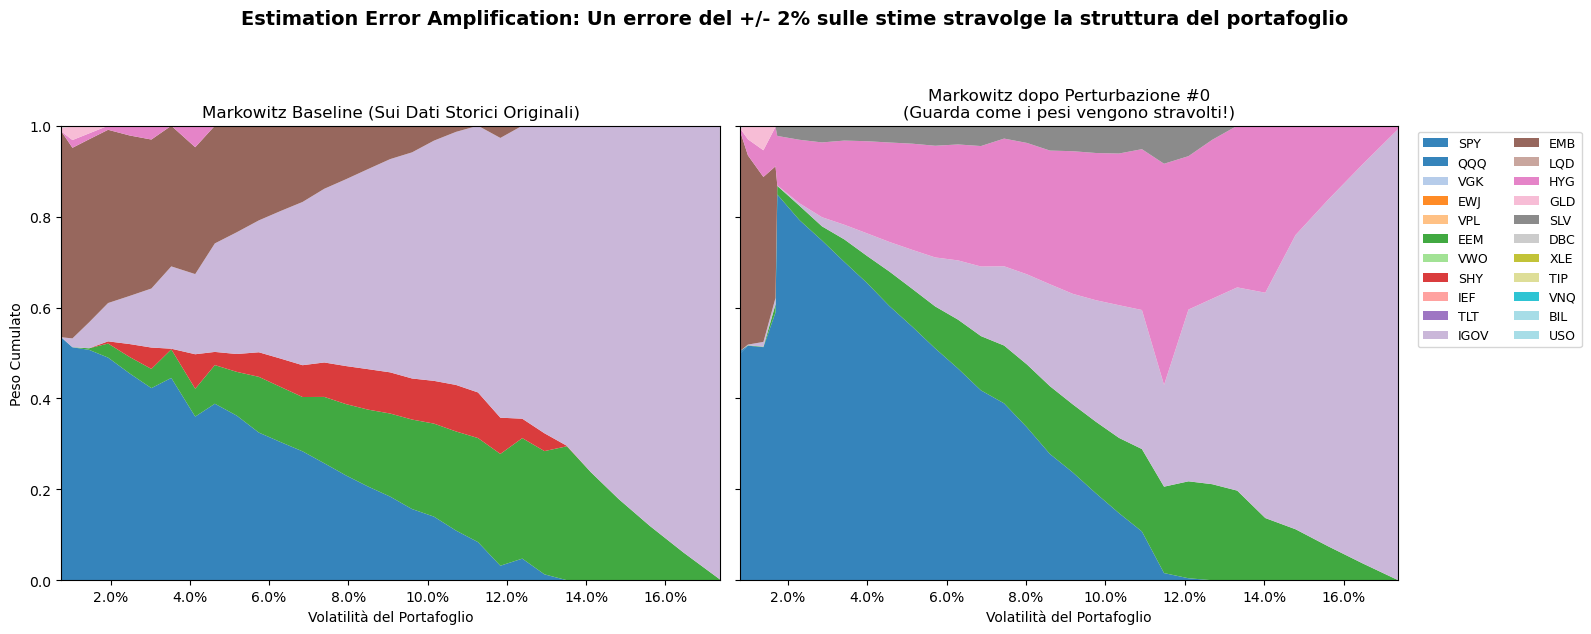

In [11]:
# 3. VISUALIZZAZIONE A: La Tabella degli Shock (Worst Case)
ex = perturbed[most_idx]
mag = np.abs(ex['eps'])
mu_down = mu_v - mag
mu_up   = mu_v + mag
chosen_up = ex['eps'] > 0
mu_chosen = ex['mu']

fig, ax = plt.subplots(figsize=(10, 8)) # Ingrandito per 22 ETF
ax.axis('off')
cell_text=[]; cell_colors=[]

for i, name in enumerate(asset_names):
    cell_text.append([name, f'{mu_v[i]*100:+.2f}%', f'{mu_down[i]*100:+.2f}%',
                      f'{mu_up[i]*100:+.2f}%', f'{mu_chosen[i]*100:+.2f}%'])
    if chosen_up[i]:
        rc = ['#fafafa','#eef2f7','#fafafa','#a8e6a8','#dfffdf'] # Verde per UP
    else:
        rc = ['#fafafa','#eef2f7','#f5a8a8','#fafafa','#ffe0e0'] # Rosso per DOWN
    cell_colors.append(rc)
    
col_labels = ['Asset', 'Mu Storico', 'Mu DOWN', 'Mu UP', 'Mu SCELTO']
tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellColours=cell_colors,
               loc='center', cellLoc='center', colWidths=[0.15, 0.18, 0.18, 0.18, 0.18])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)

for ci in range(len(col_labels)):
    tbl[(0, ci)].set_text_props(weight='bold', color='white')
    tbl[(0, ci)].set_facecolor('#404040')
    
ax.set_title(f'Dettaglio Shock: Perturbazione ad alto impatto #{most_idx}\n(Shock causale $\sim$ |N(0, 1%)|)', pad=15, fontsize=12)
plt.tight_layout()
plt.show()

# 4. VISUALIZZAZIONE B: La Nuvola di Frontiere (L'illusione di Stabilità)
fig, ax = plt.subplots(figsize=(12, 7))
for p in perturbed:
    ax.plot(p['vol'], p['ret'], color='steelblue', lw=0.9, alpha=0.55)
ax.plot(vol0, ret0, color='#d62728', lw=3, label='Frontiera Baseline (Mu Storico)')
ax.plot([], [], color='steelblue', lw=1.4, alpha=0.7,
        label=f'{len(perturbed)} Frontiere Perturbate (+/- 2% CI)')

# Plot dei singoli ETF
for i, t in enumerate(asset_names):
    ax.scatter(sigma[i], mu_v[i], s=80, marker='D', edgecolor='black', linewidth=1, color='orange', zorder=5)
    ax.annotate(t, xy=(sigma[i], mu_v[i]), xytext=(6, 4), textcoords='offset points', fontsize=9)
    
ax.set_xlabel('Volatilità Annualizzata')
ax.set_ylabel('Rendimento Atteso Annualizzato')
ax.set_title('Frontiere Perturbate (Nuvola densa: Apparente Stabilità)')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. VISUALIZZAZIONE C: Il collasso dell'allocazione (Estimation Error Amplification)
colors = plt.cm.tab20(np.linspace(0, 1, n)) # Colori per 22 asset

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Stackplot Originale
axes[0].stackplot(vol0, baseline_W.T, labels=asset_names, colors=colors, alpha=0.9)
axes[0].set_xlim(vol0.min(), vol0.max()); axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Volatilità del Portafoglio')
axes[0].set_ylabel('Peso Cumulato')
axes[0].set_title('Markowitz Baseline (Sui Dati Storici Originali)')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Stackplot Perturbato (Worst Case)
axes[1].stackplot(ex['vol'], ex['W'].T, labels=asset_names, colors=colors, alpha=0.9)
axes[1].set_xlim(ex['vol'].min(), ex['vol'].max()); axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Volatilità del Portafoglio')
axes[1].set_title(f'Markowitz dopo Perturbazione #{most_idx}\n(Guarda come i pesi vengono stravolti!)')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=2)

plt.suptitle('Estimation Error Amplification: Un errore del +/- 2% sulle stime stravolge la struttura del portafoglio', y=1.05, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
# Cella: Calcolo Metriche Oggettive (KPIs) Out-of-Sample

def calculate_kpis(returns_series, weights_df, model_name="Modello"):
    """
    Calcola le metriche oggettive di performance per un portafoglio.
    
    returns_series: pd.Series dei rendimenti mensili out-of-sample
    weights_df: pd.DataFrame storico dei pesi mese per mese
    """
    # 1. Rendimento e Volatilità Annualizzati
    ann_ret = returns_series.mean() * 12
    ann_vol = returns_series.std() * np.sqrt(12)
    
    # 2. Sharpe Ratio (Assumiamo risk-free a 0 per semplicità comparativa)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    
    # 3. Maximum Drawdown
    cum_returns = np.exp(returns_series.cumsum())
    running_max = cum_returns.cummax()
    drawdown = (cum_returns / running_max) - 1
    max_dd = drawdown.min()
    
    # 4. Calmar Ratio
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    
    # 5. Turnover Medio Mensile
    # Calcola la differenza assoluta dei pesi tra il mese t e il mese t-1
    # La somma rappresenta il volume totale scambiato. Ne prendiamo la media.
    turnover_mensile = weights_df.diff().abs().sum(axis=1).mean()
    turnover_annuo = turnover_mensile * 12 # Proiettato su base annua
    
    # Restituisce una Series ordinata
    return pd.Series({
        'Rendimento Ann.': f"{ann_ret*100:.2f}%",
        'Volatilità Ann.': f"{ann_vol*100:.2f}%",
        'Sharpe Ratio': f"{sharpe:.3f}",
        'Max Drawdown': f"{max_dd*100:.2f}%",
        'Calmar Ratio': f"{calmar:.3f}",
        'Turnover Annuo': f"{turnover_annuo*100:.2f}%"
    }, name=model_name)

# Esempio di utilizzo (quando unirete i notebook):
# Creiamo un DataFrame comparativo vuoto (simulazione)
print("Generazione Tabella Oggettiva di Confronto...")

# 1. Calcoli il tuo Michaud
kpi_michaud = calculate_kpis(michaud_strategy_returns, michaud_historical_weights, "Michaud Resampled")

# 2. Quando il tuo socio avrà i suoi dati, farà lo stesso:
# kpi_markowitz = calculate_kpis(markowitz_returns, markowitz_weights, "Markowitz Base")
# kpi_benchmark = calculate_kpis(benchmark_1_N_returns, benchmark_1_N_weights, "Equiponderato (1/N)")

# 3. Unione per la tabella finale (qui mostro solo Michaud come esempio)
tabella_finale = pd.DataFrame([kpi_michaud]).T
display(tabella_finale)